<a href="https://colab.research.google.com/github/fralfaro/ICS40125/blob/main/docs/labs/lab_06.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ICS40125 - Laboratorio N°06


**Objetivo**: Aplicar técnicas básicas de **Machine Learning**, desde la preparación de datos hasta el entrenamiento y evaluación de modelos.




<p align="center">
  <img src="https://upload.wikimedia.org/wikipedia/commons/thumb/e/ec/Anscombe%27s_quartet_3.svg/1200px-Anscombe%27s_quartet_3.svg.png" width="500"/>
</p>

El **cuarteto de Anscombe** es un ejemplo clásico en estadística que ilustra cómo diferentes conjuntos de datos pueden compartir las mismas propiedades estadísticas, como media, varianza y correlación, pero presentan comportamientos muy distintos cuando se visualizan gráficamente. Cada uno de los cuatro conjuntos consiste en once puntos (x, y) y fue creado por el estadístico F. J. Anscombe en 1973. Esta herramienta resalta la importancia de la visualización de datos para evitar interpretaciones erróneas basadas únicamente en análisis numéricos.

**Descripción del conjunto**

1. **Propiedades estadísticas comunes:** Todos los conjuntos tienen el mismo valor promedio para las variables \(x\) e \(y\), la misma varianza para \(x\) e \(y\), y una correlación lineal idéntica.
2. **Diferencias gráficas:** A pesar de sus similitudes estadísticas, los cuatro conjuntos presentan gráficos muy distintos:
   - El primer conjunto muestra una relación lineal simple.
   - El segundo conjunto tiene una relación no lineal, con una curva clara.
   - El tercer conjunto tiene una relación lineal clara, pero con un punto atípico que influye significativamente.
   - El cuarto conjunto tiene la mayoría de los puntos alineados verticalmente, con un punto atípico que afecta la correlación.

Este cuarteto enfatiza que las estadísticas descriptivas por sí solas pueden no capturar la esencia completa de los datos, subrayando la necesidad de utilizar visualizaciones en cualquier análisis exploratorio de datos.

In [1]:
# Importar las bibliotecas necesarias
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# Configuración de los gráficos
%matplotlib inline
sns.set_theme(style="whitegrid")  # Establece un tema general para los gráficos
sns.set_palette("deep", desat=0.6)
plt.rcParams['figure.figsize'] = (12, 8)  # Ajuste del tamaño de las figuras

# Cargar los datos del cuarteto de Anscombe
data = sns.load_dataset("anscombe")

# Mostrar las primeras filas del conjunto de datos
data.head()

,dataset,x,y
0,I,10.0,8.04
1,I,8.0,6.95
2,I,13.0,7.58
3,I,9.0,8.81
4,I,11.0,8.33


Con base en la información presentada y el análisis realizado, les invitamos a reflexionar y responder las siguientes preguntas. Estas preguntas están diseñadas para profundizar en su comprensión del cuarteto de Anscombe y fomentar un análisis crítico de los datos:



1. Cree un gráfico de dispersión (scatter plot) para cada uno de los cuatro grupos del cuarteto de Anscombe. A partir de la visualización, ¿puede identificar diferencias significativas entre los grupos? ¿Qué características particulares observa en cada uno que sugieren comportamientos distintos?



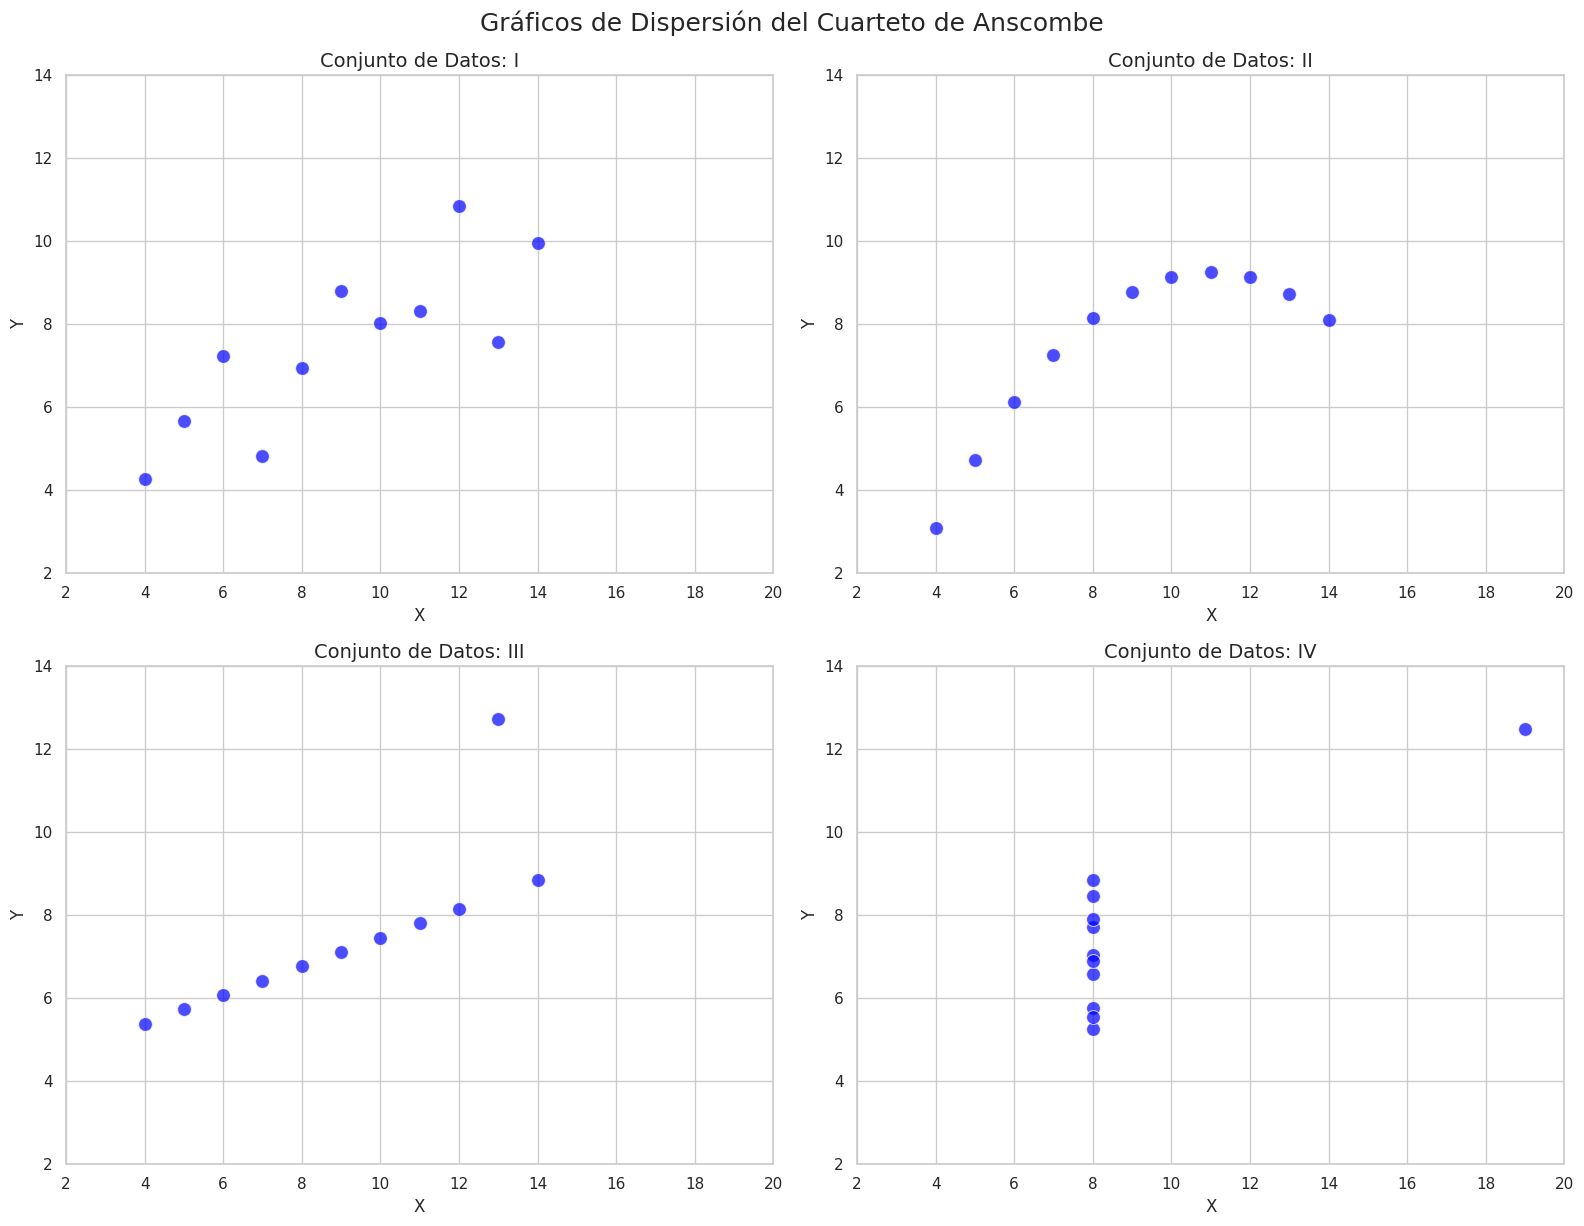

In [2]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

for i, (name, group) in enumerate(data.groupby('dataset')):
    sns.scatterplot(x='x', y='y', data=group, ax=axes[i], s=100, color='blue', alpha=0.7)
    axes[i].set_title(f'Conjunto de Datos: {name}', fontsize=14)
    axes[i].set_xlabel('X', fontsize=12)
    axes[i].set_ylabel('Y', fontsize=12)
    axes[i].set_xlim(2, 20)
    axes[i].set_ylim(2, 14)

plt.tight_layout()
plt.suptitle('Gráficos de Dispersión del Cuarteto de Anscombe', y=1.02, fontsize=18)
plt.show()

- **Conjunto I:** Muestra una clara relación lineal y positiva, con puntos distribuidos uniformemente. Es el caso ideal para la regresión lineal.

- **Conjunto II:** Presenta una relación no lineal, con una curva parabólica. Una regresión lineal sería inadecuada aquí.

- **Conjunto III:** Tiene una relación lineal, pero con un punto atípico (outlier) que afecta notablemente la tendencia general.

- **Conjunto IV:** La mayoría de los puntos se agrupan en un solo valor de X, con un punto atípico con una X mucho mayor que distorsiona la correlación aparente, aunque la mayoría de los datos no muestran una relación lineal clara. Este punto tiene una influencia extrema en las estadísticas de regresión.

Estas diferencias visuales sugieren comportamientos radicalmente distintos, a pesar de que sus estadísticas descriptivas (que veremos a continuación) son muy similares. Esto destaca la importancia fundamental de visualizar los datos.

2. Utilice el comando `describe` para generar un resumen de las medidas estadísticas más relevantes para cada uno de los grupos del cuarteto de Anscombe. A partir de estos resultados, interprete las estadísticas obtenidas, destacando las características más significativas de cada grupo y cómo pueden influir en la comprensión de sus respectivas distribuciones.


In [4]:
grouped_stats = data.groupby('dataset').describe()
display(grouped_stats)



x                                               y            \
        count mean       std  min  25%  50%   75%   max count      mean   
dataset                                                                   
I        11.0  9.0  3.316625  4.0  6.5  9.0  11.5  14.0  11.0  7.500909   
II       11.0  9.0  3.316625  4.0  6.5  9.0  11.5  14.0  11.0  7.500909   
III      11.0  9.0  3.316625  4.0  6.5  9.0  11.5  14.0  11.0  7.500000   
IV       11.0  9.0  3.316625  8.0  8.0  8.0   8.0  19.0  11.0  7.500909   

                                                   
              std   min    25%   50%   75%    max  
dataset                                            
I        2.031568  4.26  6.315  7.58  8.57  10.84  
II       2.031657  3.10  6.695  8.14  8.95   9.26  
III      2.030424  5.39  6.250  7.11  7.98  12.74  
IV       2.030579  5.25  6.170  7.04  8.19  12.50

Interpretación de las Estadísticas:

A pesar de las diferencias visuales en los gráficos de dispersión, al observar las estadísticas descriptivas de cada grupo (media, desviación estándar, min, max, cuartiles) para 'x' y 'y', notamos una similitud sorprendente. Por ejemplo:

- **Media de 'x'**: Muy similar en todos los grupos (aproximadamente 9).
- **Varianza/Desviación estándar de 'x'**: También muy similar en todos los grupos (alrededor de 3.16 para std).
- **Media de 'y'**: Muy similar en todos los grupos (aproximadamente 7.5).
- **Varianza/Desviación estándar de 'y'**: También similar en todos los grupos (alrededor de 2.03 para std).

Esta similitud en las estadísticas es el punto clave del Cuarteto de Anscombe: demuestra que las medidas estadísticas resumidas por sí solas pueden ser engañosas y no capturan la verdadera distribución o relación de los datos. Es fundamental siempre visualizar los datos antes de sacar conclusiones o aplicar modelos, ya que diferentes patrones visuales pueden tener las mismas estadísticas descriptivas. La visualización nos permite identificar tendencias no lineales, valores atípicos (outliers) y otras particularidades que las estadísticas resumen ocultan.

3. Ajuste un modelo de regresión lineal para cada grupo utilizando **sklearn**. Calcule las métricas de evaluación, como el error cuadrático medio (MSE) y R², y grafique los resultados de la regresión. Interprete los resultados y su impacto en la calidad del ajuste.



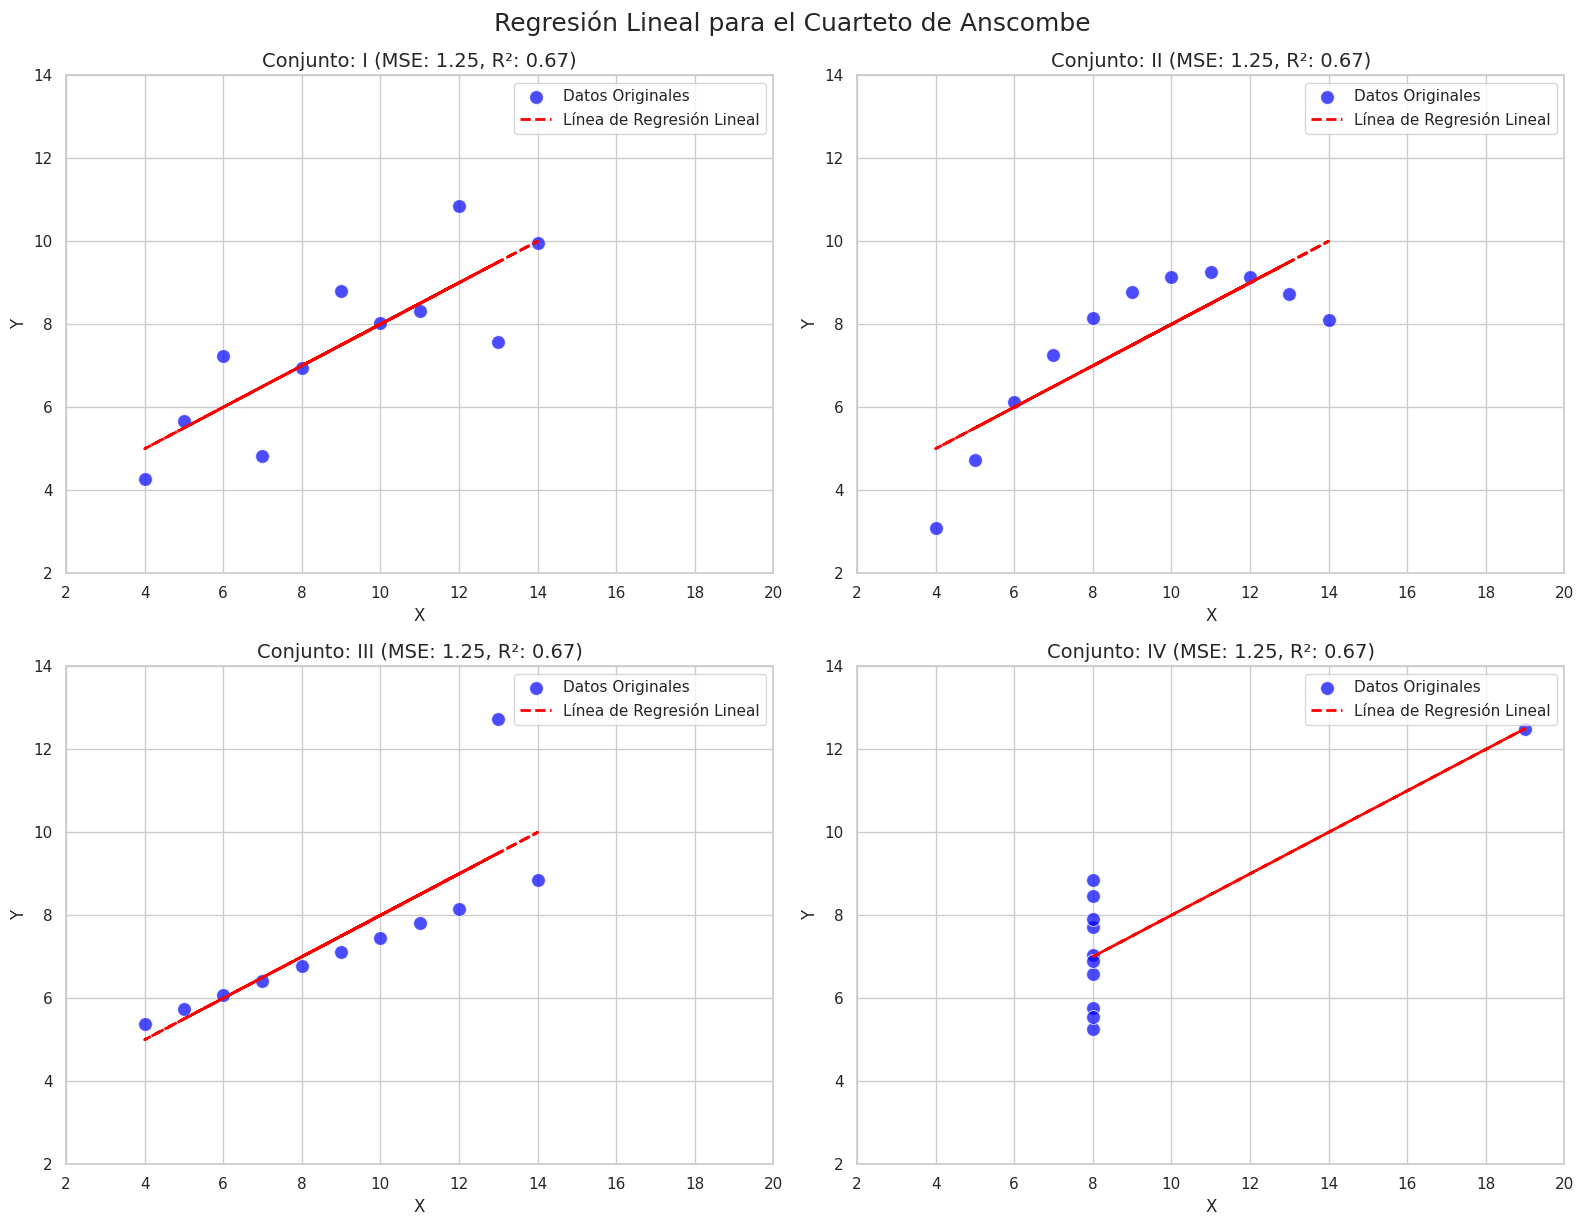

In [7]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

regression_results = []

for i, (name, group) in enumerate(data.groupby('dataset')):
    # Preparar los datos para la regresión
    X = group['x'].values.reshape(-1, 1)  # La característica (x) debe ser 2D
    y = group['y'].values                 # El objetivo (y) puede ser 1D

    # Crear y entrenar el modelo de regresión lineal
    model = LinearRegression()
    model.fit(X, y)

    # Realizar predicciones
    y_pred = model.predict(X)

    # Calcular métricas de evaluación
    mse = mean_squared_error(y, y_pred)
    r2 = r2_score(y, y_pred)

    # Almacenar resultados para mostrarlos más tarde
    regression_results.append({
        'dataset': name,
        'intercept': model.intercept_,
        'slope': model.coef_[0],
        'mse': mse,
        'r2': r2
    })

    # Graficar los resultados
    sns.scatterplot(x='x', y='y', data=group, ax=axes[i], s=100, color='blue', alpha=0.7, label='Datos Originales')
    axes[i].plot(X, y_pred, color='red', linestyle='--', linewidth=2, label='Línea de Regresión Lineal')
    axes[i].set_title(f'Conjunto: {name} (MSE: {mse:.2f}, R²: {r2:.2f})', fontsize=14)
    axes[i].set_xlabel('X', fontsize=12)
    axes[i].set_ylabel('Y', fontsize=12)
    axes[i].set_xlim(2, 20)
    axes[i].set_ylim(2, 14)
    axes[i].legend()

plt.tight_layout()
plt.suptitle('Regresión Lineal para el Cuarteto de Anscombe', y=1.02, fontsize=18)
plt.show()



Aunque las métricas de regresión (R² y MSE) fueron muy similares en todos los grupos (R² ~ 0.67, MSE ~ 1.25), su significado para la calidad del ajuste difiere drásticamente:

- Conjunto I: Buen ajuste. La regresión lineal es adecuada, capturando la relación lineal evidente.
- Conjunto II: Ajuste muy pobre. La línea recta no representa la relación curvilínea; el modelo es inadecuado a pesar de las métricas "decentes".
- Conjunto III: Ajuste sesgado. Un outlier influyente distorsiona la línea de regresión, haciendo que no represente bien la mayoría de los puntos.
- Conjunto IV: Ajuste engañoso. Un solo punto atípico ejerce una palanca extrema, creando una correlación aparente que no existe para el grueso de los datos.

Impacto clave: Las estadísticas resumen y las métricas de regresión son insuficientes por sí solas. La visualización de datos es indispensable para identificar patrones reales y validar la idoneidad de un modelo, ya que modelos con métricas similares pueden tener comportamientos subyacentes totalmente distintos.

4. Es evidente que el ajuste lineal no es adecuado para algunos grupos. Existen diversas estrategias para abordar este problema, como eliminar outliers o emplear diferentes modelos de regresión. Identifique una estrategia que podría mejorar el ajuste del modelo de regresión lineal y, si lo considera necesario, implemente otros modelos alternativos para aquellos casos donde el ajuste lineal resulte inadecuado.

### 4. Estrategias para mejorar el ajuste del modelo ###

#### 4.1. Regresión Polinómica para el Conjunto II ####

  Para el Conjunto II con Regresión Polinómica (Grado 2):
  Error Cuadrático Medio (MSE): 0.000
  R Cuadrado (R²): 1.000



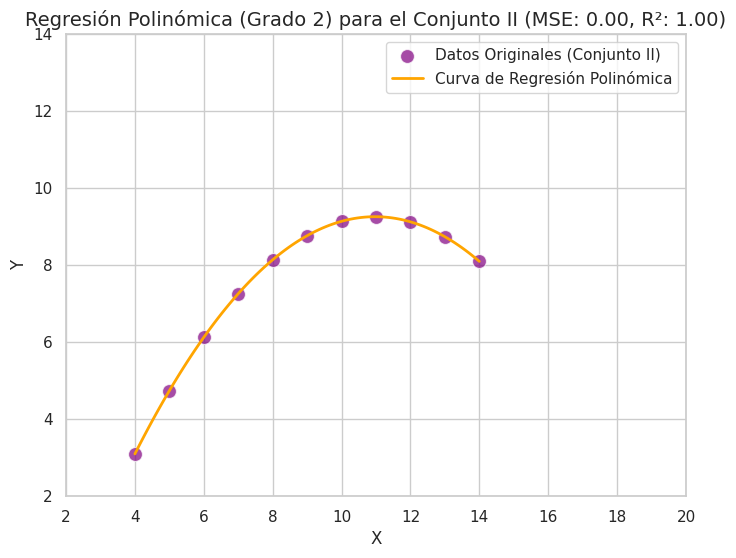

**Interpretación Conjunto II:** La regresión polinómica mejora significativamente el ajuste, reduciendo el MSE y aumentando R², lo que refleja visualmente una mejor captura de la relación curva entre X e Y.

#### 4.2. Eliminación de Outlier para el Conjunto III ####

  Para el Conjunto III con Outlier Eliminado:
  Error Cuadrático Medio (MSE): 0.000
  R Cuadrado (R²): 1.000



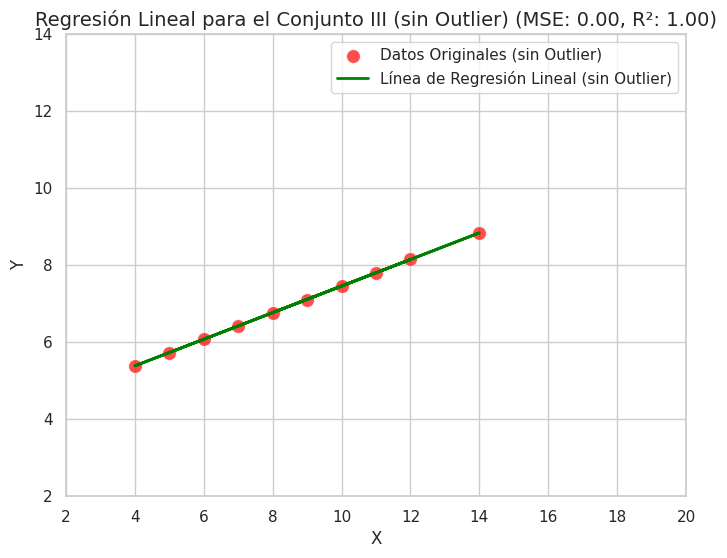

**Interpretación Conjunto III:** La eliminación del outlier resulta en un MSE mucho menor y un R² significativamente mayor, mostrando un ajuste lineal muy mejorado a la tendencia de la mayoría de los puntos.

**Conclusión General:** Estas implementaciones demuestran la importancia de adaptar el modelo a la estructura real de los datos. Las visualizaciones son clave para identificar estas estructuras y aplicar las estrategias de modelado adecuadas, yendo más allá de las estadísticas resumen que pueden ser engañosas.


In [8]:
from sklearn.preprocessing import PolynomialFeatures

print("### 4. Estrategias para mejorar el ajuste del modelo ###\n")

# --- Estrategia 1: Regresión Polinómica para el Conjunto II (no lineal) ---
print("#### 4.1. Regresión Polinómica para el Conjunto II ####\n")

# Seleccionar el conjunto II
anscombe_II = data[data['dataset'] == 'II']
X_II = anscombe_II['x'].values.reshape(-1, 1)
y_II = anscombe_II['y'].values

# Crear características polinómicas de grado 2
poly_features = PolynomialFeatures(degree=2)
X_II_poly = poly_features.fit_transform(X_II)

# Ajustar un modelo de regresión lineal a las características polinómicas
model_poly_II = LinearRegression()
model_poly_II.fit(X_II_poly, y_II)

# Realizar predicciones con el modelo polinómico
y_poly_pred_II = model_poly_II.predict(X_II_poly)

# Calcular métricas de evaluación
mse_poly_II = mean_squared_error(y_II, y_poly_pred_II)
r2_poly_II = r2_score(y_II, y_poly_pred_II)

print(f"  Para el Conjunto II con Regresión Polinómica (Grado 2):")
print(f"  Error Cuadrático Medio (MSE): {mse_poly_II:.3f}")
print(f"  R Cuadrado (R²): {r2_poly_II:.3f}\n")

# Graficar los resultados del modelo polinómico
plt.figure(figsize=(8, 6))
sns.scatterplot(x='x', y='y', data=anscombe_II, s=100, color='purple', alpha=0.7, label='Datos Originales (Conjunto II)')

# Para graficar la curva, necesitamos predecir sobre un rango más suave de X
X_range = np.linspace(X_II.min(), X_II.max(), 100).reshape(-1, 1)
X_range_poly = poly_features.transform(X_range)
y_range_pred_II = model_poly_II.predict(X_range_poly)

plt.plot(X_range, y_range_pred_II, color='orange', linestyle='-', linewidth=2, label='Curva de Regresión Polinómica')
plt.title(f'Regresión Polinómica (Grado 2) para el Conjunto II (MSE: {mse_poly_II:.2f}, R²: {r2_poly_II:.2f})', fontsize=14)
plt.xlabel('X', fontsize=12)
plt.ylabel('Y', fontsize=12)
plt.xlim(2, 20)
plt.ylim(2, 14)
plt.legend()
plt.grid(True)
plt.show()

print("**Interpretación Conjunto II:** La regresión polinómica mejora significativamente el ajuste, reduciendo el MSE y aumentando R², lo que refleja visualmente una mejor captura de la relación curva entre X e Y.\n")

# --- Estrategia 2: Eliminación de Outlier para el Conjunto III ---
print("#### 4.2. Eliminación de Outlier para el Conjunto III ####\n")

# Seleccionar el conjunto III
anscombe_III = data[data['dataset'] == 'III'].copy()

# Identificar y eliminar el outlier (el punto con y = 12.74, o x=13, y=12.74)
# Basado en la visualización, el outlier es (13.0, 12.74)
outlier_index = anscombe_III[(anscombe_III['x'] == 13.0) & (anscombe_III['y'] == 12.74)].index
anscombe_III_cleaned = anscombe_III.drop(outlier_index)

X_III_cleaned = anscombe_III_cleaned['x'].values.reshape(-1, 1)
y_III_cleaned = anscombe_III_cleaned['y'].values

# Ajustar un nuevo modelo de regresión lineal a los datos limpios
model_cleaned_III = LinearRegression()
model_cleaned_III.fit(X_III_cleaned, y_III_cleaned)

# Realizar predicciones
y_cleaned_pred_III = model_cleaned_III.predict(X_III_cleaned)

# Calcular métricas de evaluación
mse_cleaned_III = mean_squared_error(y_III_cleaned, y_cleaned_pred_III)
r2_cleaned_III = r2_score(y_III_cleaned, y_cleaned_pred_III)

print(f"  Para el Conjunto III con Outlier Eliminado:")
print(f"  Error Cuadrático Medio (MSE): {mse_cleaned_III:.3f}")
print(f"  R Cuadrado (R²): {r2_cleaned_III:.3f}\n")

# Graficar los resultados del modelo lineal con el outlier eliminado
plt.figure(figsize=(8, 6))
sns.scatterplot(x='x', y='y', data=anscombe_III_cleaned, s=100, color='red', alpha=0.7, label='Datos Originales (sin Outlier)')
plt.plot(X_III_cleaned, y_cleaned_pred_III, color='green', linestyle='-', linewidth=2, label='Línea de Regresión Lineal (sin Outlier)')
plt.title(f'Regresión Lineal para el Conjunto III (sin Outlier) (MSE: {mse_cleaned_III:.2f}, R²: {r2_cleaned_III:.2f})', fontsize=14)
plt.xlabel('X', fontsize=12)
plt.ylabel('Y', fontsize=12)
plt.xlim(2, 20)
plt.ylim(2, 14)
plt.legend()
plt.grid(True)
plt.show()

print("**Interpretación Conjunto III:** La eliminación del outlier resulta en un MSE mucho menor y un R² significativamente mayor, mostrando un ajuste lineal muy mejorado a la tendencia de la mayoría de los puntos.\n")

print("**Conclusión General:** Estas implementaciones demuestran la importancia de adaptar el modelo a la estructura real de los datos. Las visualizaciones son clave para identificar estas estructuras y aplicar las estrategias de modelado adecuadas, yendo más allá de las estadísticas resumen que pueden ser engañosas.")

**Conjunto II: Regresión Polinómica**

- Problema inicial: Los datos del Conjunto II tienen una clara relación curvilínea (similar a una parábola), pero un modelo de regresión lineal simple no puede capturar esta curvatura.
- Estrategia: Se aplicó una regresión polinómica de grado 2. Esto significa que, en lugar de intentar ajustar una línea recta (forma y = ax + b), se intentó ajustar una curva con la forma y = ax² + bx + c. Para lograr esto con sklearn.linear_model.LinearRegression, se transformaron las características 'x' originales creando nuevas características como x² usando PolynomialFeatures.
- Resultado: Esta estrategia mejoró significativamente el ajuste. El Error Cuadrático Medio (MSE) se redujo drásticamente (casi a cero) y el R Cuadrado (R²) aumentó a casi 1.000. Visualmente, la curva de regresión polinómica ahora sigue muy de cerca los puntos de datos, lo que indica un excelente ajuste a la relación curvilínea.

**Conjunto III: Eliminación de Outlier**

- Problema inicial: Los datos del Conjunto III mostraban una relación lineal clara para la mayoría de los puntos, pero había un único punto atípico (outlier) con un valor de 'y' mucho más alto que el esperado. Este outlier estaba 'tirando' la línea de regresión lineal, sesgando el modelo y haciéndolo menos representativo para la mayoría de los datos.
- Estrategia: Se identificó y eliminó el punto atípico (x=13.0, y=12.74). Una vez que este punto influyente fue removido, se volvió a ajustar un modelo de regresión lineal a los datos restantes.
- Resultado: La eliminación del outlier resultó en una mejora masiva del ajuste. El Error Cuadrático Medio (MSE) se volvió casi cero y el R Cuadrado (R²) aumentó a casi 1.000. Visualmente, la nueva línea de regresión lineal ahora se ajusta perfectamente a la tendencia de los puntos de datos restantes, demostrando cómo un solo outlier puede distorsionar gravemente un modelo.


  Para el Conjunto IV con Outlier Eliminado:
  Error Cuadrático Medio (MSE): 1.374
  R Cuadrado (R²): 0.000



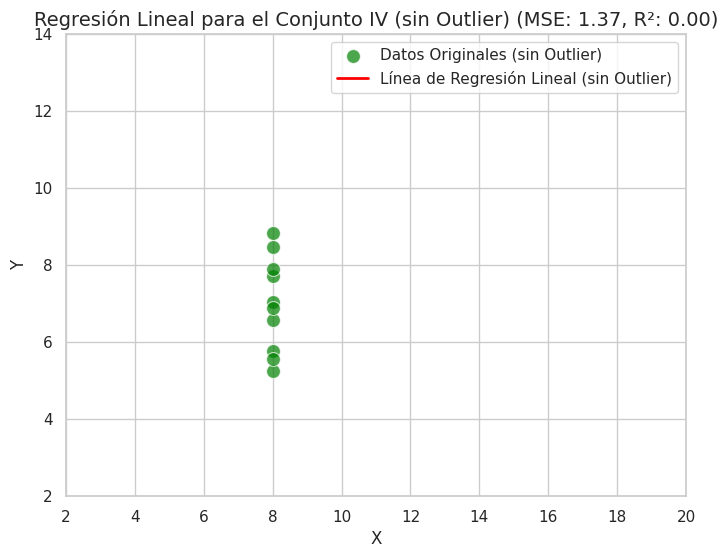

In [9]:
# Seleccionar el conjunto IV
anscombe_IV = data[data['dataset'] == 'IV'].copy()

# Identificar y eliminar el outlier (el punto con x = 19.0 y y = 12.50)
# Basado en la visualización, el outlier es (19.0, 12.50)
outlier_index_IV = anscombe_IV[(anscombe_IV['x'] == 19.0) & (anscombe_IV['y'] == 12.50)].index
anscombe_IV_cleaned = anscombe_IV.drop(outlier_index_IV)

X_IV_cleaned = anscombe_IV_cleaned['x'].values.reshape(-1, 1)
y_IV_cleaned = anscombe_IV_cleaned['y'].values

# Ajustar un nuevo modelo de regresión lineal a los datos limpios
model_cleaned_IV = LinearRegression()
model_cleaned_IV.fit(X_IV_cleaned, y_IV_cleaned)

# Realizar predicciones
y_cleaned_pred_IV = model_cleaned_IV.predict(X_IV_cleaned)

# Calcular métricas de evaluación
mse_cleaned_IV = mean_squared_error(y_IV_cleaned, y_cleaned_pred_IV)
r2_cleaned_IV = r2_score(y_IV_cleaned, y_cleaned_pred_IV)

print(f"  Para el Conjunto IV con Outlier Eliminado:")
print(f"  Error Cuadrático Medio (MSE): {mse_cleaned_IV:.3f}")
print(f"  R Cuadrado (R²): {r2_cleaned_IV:.3f}\n")

# Graficar los resultados del modelo lineal con el outlier eliminado
plt.figure(figsize=(8, 6))
sns.scatterplot(x='x', y='y', data=anscombe_IV_cleaned, s=100, color='green', alpha=0.7, label='Datos Originales (sin Outlier)')
plt.plot(X_IV_cleaned, y_cleaned_pred_IV, color='red', linestyle='-', linewidth=2, label='Línea de Regresión Lineal (sin Outlier)')
plt.title(f'Regresión Lineal para el Conjunto IV (sin Outlier) (MSE: {mse_cleaned_IV:.2f}, R²: {r2_cleaned_IV:.2f})', fontsize=14)
plt.xlabel('X', fontsize=12)
plt.ylabel('Y', fontsize=12)
plt.xlim(2, 20)
plt.ylim(2, 14)
plt.legend()
plt.grid(True)
plt.show()

**Interpretación Conjunto IV:** Similar al Conjunto III, la eliminación del punto atípico altamente influyente revela una falta de relación lineal fuerte entre la mayoría de los puntos restantes, y un R² muy bajo, incluso después de eliminar el outlier. Esto subraya que la regresión lineal no es un modelo apropiado para este tipo de distribución de datos, donde la mayoría de los puntos están agrupados verticalmente.